In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

## Carga dataset

In [ ]:
df_crimes = pd.read_csv("/content/chicago_crimes_and_stations_2024_processed.csv")
df_crimes.drop(['Unnamed: 0', 'Location Description'], axis=1, inplace=True)
df_crimes.head()

,IUCR,Primary Type,Arrest,Domestic,Beat,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Latitude,Longitude,Crime District,Nearest Police Station District,Nearest Police Station District Name,Distance Crime To Police Station,Season,Day,Day Time
0,1310,CRIMINAL DAMAGE,False,False,332,5,43,14,1186817.0,1860189.0,41.771470,-87.605748,3,3,Grand Crossing,1367.540845,Winter,Tuesday,Night
1,1365,CRIMINAL TRESPASS,True,True,223,3,38,26,1179661.0,1873623.0,41.808501,-87.630560,2,2,Wentworth,1380.313916,Winter,Tuesday,Night
2,0498,BATTERY,False,True,834,18,70,04B,1145740.0,1853048.0,41.752749,-87.708864,8,8,Chicago Lawn,3982.098345,Winter,Tuesday,Night
3,1320,CRIMINAL DAMAGE,False,False,321,20,42,14,1184362.0,1861188.0,41.774269,-87.605748,3,3,Grand Crossing,1005.009383,Winter,Tuesday,Night
4,0460,BATTERY,False,False,2531,29,25,08B,1137458.0,1907694.0,41.902858,-87.765574,25,25,Grand Central,1797.243049,Winter,Tuesday,Night


In [ ]:
df_crimes.dtypes

,0
IUCR,object
Primary Type,object
Arrest,bool
Domestic,bool
Beat,int64
Ward,int64
Community Area,int64
FBI Code,object
X Coordinate,float64
Y Coordinate,float64


In [ ]:
df_crimes.describe()

,Beat,Ward,Community Area,X Coordinate,Y Coordinate,Latitude,Longitude,Crime District,Distance Crime To Police Station
count,257514.000000,257514.000000,257514.000000,2.575140e+05,2.575140e+05,257514.000000,257514.000000,257514.000000,257514.000000
mean,1157.056339,23.185023,36.182437,1.165281e+06,1.887738e+06,41.847534,-87.668927,11.340712,1998.281721
std,709.339850,13.950074,21.606347,1.616071e+04,3.153780e+04,0.086723,0.051320,7.088088,1213.955887
min,111.000000,1.000000,1.000000,1.092647e+06,1.813897e+06,41.644590,-87.768200,1.000000,12.262025
25%,533.000000,10.000000,22.000000,1.154005e+06,1.860559e+06,41.772692,-87.705488,5.000000,1219.384303
50%,1034.000000,23.000000,32.000000,1.167128e+06,1.894416e+06,41.866093,-87.656973,10.000000,1852.857265
75%,1732.000000,34.000000,53.000000,1.176638e+06,1.910460e+06,41.910074,-87.630560,17.000000,2509.772804
max,2535.000000,50.000000,77.000000,1.205119e+06,1.951493e+06,42.022548,-87.568349,31.000000,14166.024970


## Dataset split

In [ ]:
df, test_df = train_test_split(df_crimes, test_size=0.2, random_state=42)

print(df.shape, test_df.shape)

(206011, 19) (51503, 19)


In [ ]:
df['Arrest'].value_counts()

,count
Arrest,
False,177577
True,28434


In [ ]:
test_df['Arrest'].value_counts()

,count
Arrest,
False,44443
True,7060


## Tratamiento de outliers

In [ ]:
# df = df.sort_index()
df_transformed = df.sort_index().copy()
df_transformed['Distance Crime To Police Station'] = np.log1p(df_transformed['Distance Crime To Police Station'])
df_transformed = df_transformed.sort_index()
df_transformed.describe()

,Beat,Ward,Community Area,X Coordinate,Y Coordinate,Latitude,Longitude,Crime District,Distance Crime To Police Station
count,206011.000000,206011.000000,206011.000000,2.060110e+05,2.060110e+05,206011.000000,206011.000000,206011.000000,206011.000000
mean,1158.259020,23.206008,36.131449,1.165241e+06,1.887792e+06,41.847685,-87.669058,11.352850,7.414587
std,708.702146,13.933559,21.604588,1.615144e+04,3.150128e+04,0.086622,0.051311,7.081921,0.678337
min,111.000000,1.000000,1.000000,1.092647e+06,1.813897e+06,41.644590,-87.768200,1.000000,2.584905
25%,533.000000,10.000000,22.000000,1.153973e+06,1.860614e+06,41.772849,-87.705488,5.000000,7.106921
50%,1034.000000,24.000000,32.000000,1.167108e+06,1.894487e+06,41.866262,-87.656973,10.000000,7.524312
75%,1732.000000,34.000000,53.000000,1.176621e+06,1.910502e+06,41.910115,-87.630560,17.000000,7.827958
max,2535.000000,50.000000,77.000000,1.205119e+06,1.951493e+06,42.022548,-87.568349,31.000000,9.558440


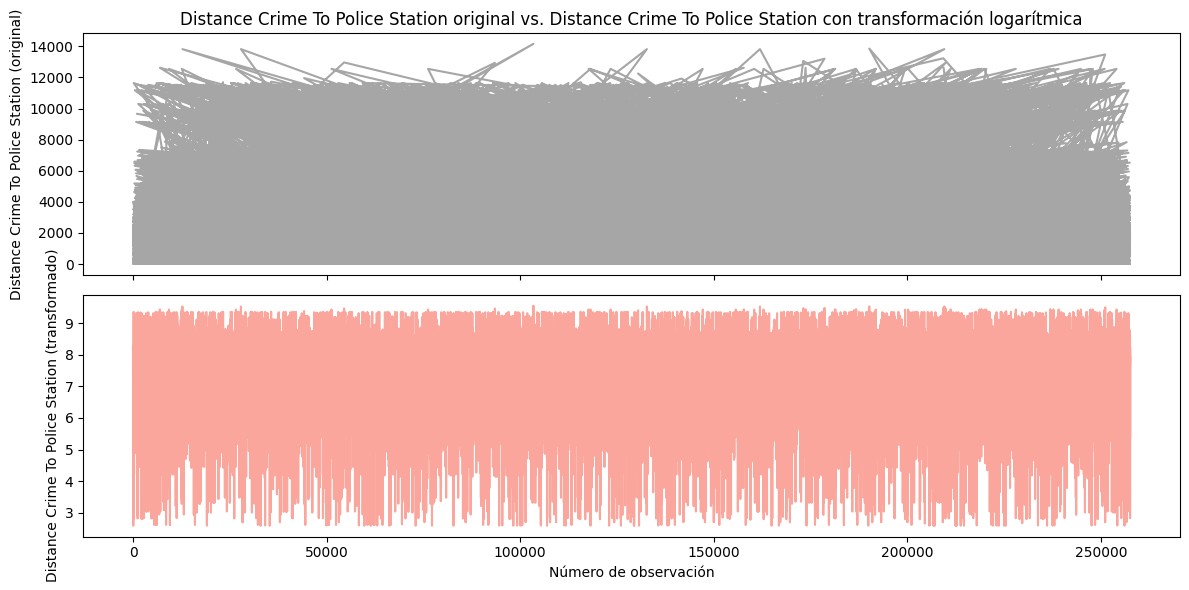

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 6), sharex=True)

# Primer gráfico: datos originales
axes[0].plot(df.index, df['Distance Crime To Police Station'], alpha=0.7, color='gray')
axes[0].set_ylabel('Distance Crime To Police Station (original)')
axes[0].set_title('Distance Crime To Police Station original vs. Distance Crime To Police Station con transformación logarítmica')

# Segundo gráfico: datos imputados
axes[1].plot(df_transformed.index, df_transformed['Distance Crime To Police Station'], alpha=0.7, color='salmon')
axes[1].set_ylabel('Distance Crime To Police Station (transformado)')
axes[1].set_xlabel('Número de observación')

plt.tight_layout()
plt.show()

In [ ]:
df_for_outliers = df_transformed[['Distance Crime To Police Station']]

In [ ]:
Q1 = df_for_outliers.quantile(0.25)
Q3 = df_for_outliers.quantile(0.75)

IQR = Q3 - Q1
outliers_iqr = (df_for_outliers < (Q1 - 1.5 * IQR)) | (df_for_outliers > (Q3 + 1.5 * IQR))
print(f"Outliers\nDistance Crime To Police Station: <{Q1['Distance Crime To Police Station'] - 1.5 * IQR['Distance Crime To Police Station']:.02f} o >{Q3['Distance Crime To Police Station'] + 1.5 * IQR['Distance Crime To Police Station']:.02f}")

Outliers
Distance Crime To Police Station: <6.03 o >8.91


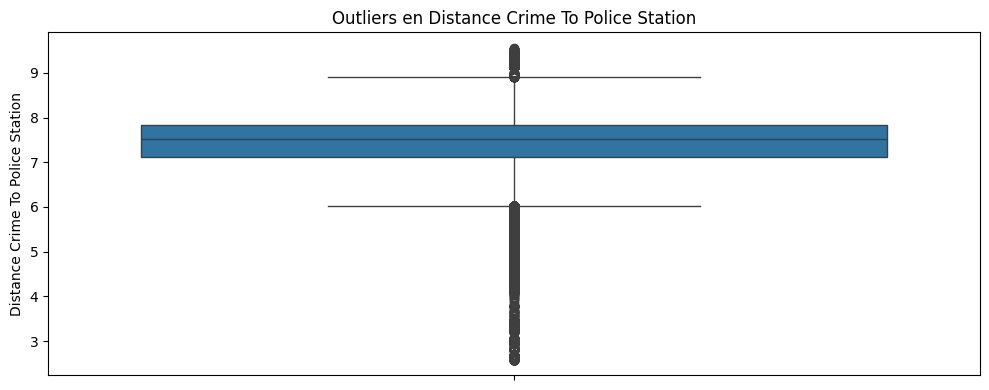

In [ ]:
# Visualización de outliers con boxplots
fig, axes = plt.subplots(1, figsize=(10, 4))

# Boxplot para 'Distance Crime To Police Station'
sns.boxplot(y=df_for_outliers['Distance Crime To Police Station'], ax=axes)
axes.set_title('Outliers en Distance Crime To Police Station')

plt.tight_layout()
plt.show()

In [ ]:
# Método basado en desviación estándar
mean = df_for_outliers.mean()
std = df_for_outliers.std()
# std = df_transformed.apply(lambda x: np.nanstd(x, ddof=1))

outliers_std = (df_for_outliers < (mean - 3 * std)) | (df_for_outliers > (mean + 3 * std))

print(f"Outliers\nDistance Crime To Police Station: <{mean['Distance Crime To Police Station'] - 3 * std['Distance Crime To Police Station']:.02f} o >{mean['Distance Crime To Police Station'] + 3 * std['Distance Crime To Police Station']:.02f}")

Outliers
Distance Crime To Police Station: <5.38 o >9.45


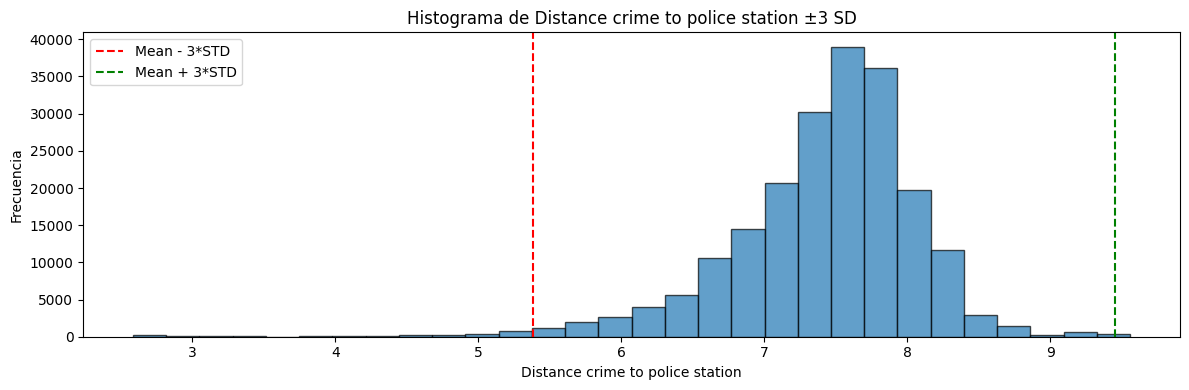

In [ ]:
def plot_hist_with_std(ax, data, varname, mean, std):
    ax.hist(data, bins=30, edgecolor='black', alpha=0.7)
    ax.axvline(mean[varname] - 3*std[varname], color='red', linestyle='--', label='Mean - 3*STD')
    ax.axvline(mean[varname] + 3*std[varname], color='green', linestyle='--', label='Mean + 3*STD')
    ax.set_xlabel(varname.capitalize())
    ax.set_ylabel('Frecuencia')
    ax.set_title(f'Histograma de {varname.capitalize()} ±3 SD')
    ax.legend()

fig, ax = plt.subplots(1, figsize=(12, 4))

plot_hist_with_std(ax, df_for_outliers['Distance Crime To Police Station'], 'Distance Crime To Police Station', mean, std)

plt.tight_layout()
plt.show()

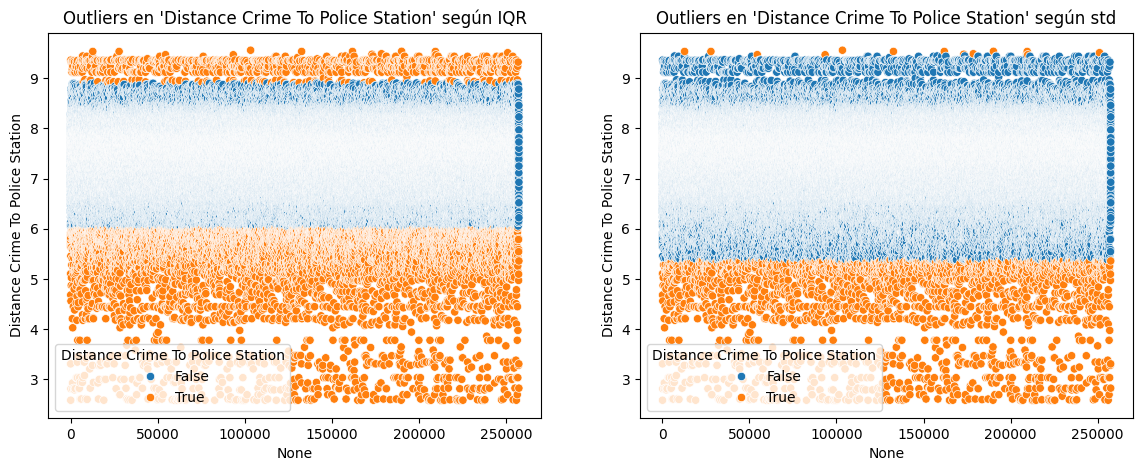

In [ ]:
# Visualización con scatterplot
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(x=df_for_outliers.index, y=df_for_outliers['Distance Crime To Police Station'], hue=outliers_iqr['Distance Crime To Police Station'], ax=ax[0])
ax[0].set_title("Outliers en 'Distance Crime To Police Station' según IQR")
sns.scatterplot(x=df_for_outliers.index, y=df_for_outliers['Distance Crime To Police Station'], hue=outliers_std['Distance Crime To Police Station'], ax=ax[1])
ax[1].set_title("Outliers en 'Distance Crime To Police Station' según std")
plt.show()

In [ ]:
df_transformed[outliers_std['Distance Crime To Police Station']==True]["Arrest"].value_counts()

,count
Arrest,
False,1957
True,579


In [ ]:
df_no_outliers = df_transformed[~outliers_std.any(axis=1)]
df_no_outliers.describe()

,Beat,Ward,Community Area,X Coordinate,Y Coordinate,Latitude,Longitude,Crime District,Distance Crime To Police Station
count,203475.000000,203475.000000,203475.000000,2.034750e+05,2.034750e+05,203475.000000,203475.000000,203475.000000,203475.000000
mean,1157.158752,23.207367,36.179339,1.165249e+06,1.887717e+06,41.847480,-87.669038,11.341796,7.450139
std,709.260377,13.934950,21.580178,1.618173e+04,3.152226e+04,0.086680,0.051376,7.087380,0.593781
min,111.000000,1.000000,1.000000,1.097306e+06,1.813897e+06,41.644590,-87.768200,1.000000,5.379825
25%,533.000000,10.000000,22.000000,1.153900e+06,1.860531e+06,41.772655,-87.705488,5.000000,7.128718
50%,1034.000000,23.000000,32.000000,1.167089e+06,1.894486e+06,41.866255,-87.656973,10.000000,7.533809
75%,1732.000000,34.000000,53.000000,1.176650e+06,1.910455e+06,41.910064,-87.630560,17.000000,7.832032
max,2535.000000,50.000000,77.000000,1.205119e+06,1.951493e+06,42.022548,-87.568349,31.000000,9.443448


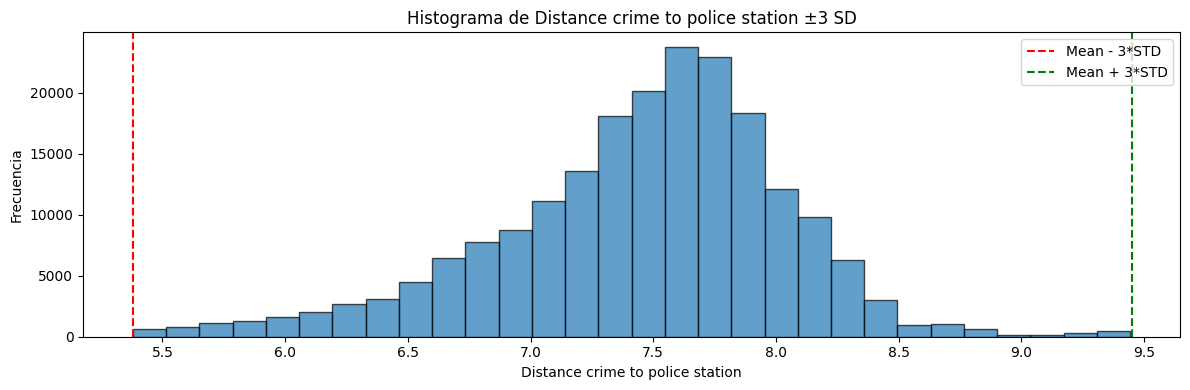

In [ ]:
fig, ax = plt.subplots(1, figsize=(12, 4))

plot_hist_with_std(ax, df_no_outliers['Distance Crime To Police Station'], 'Distance Crime To Police Station', mean, std)

plt.tight_layout()
plt.show()

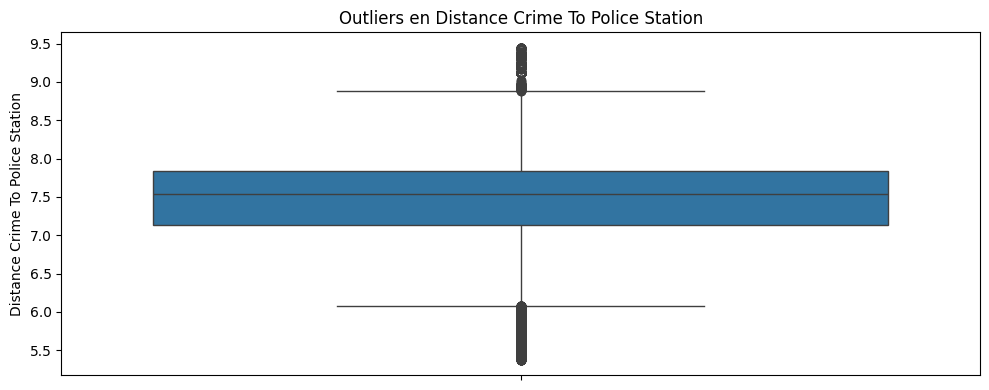

In [ ]:
# Visualización de outliers con boxplots
fig, axes = plt.subplots(1, figsize=(10, 4))

# Boxplot para 'Distance Crime To Police Station'
sns.boxplot(y=df_no_outliers['Distance Crime To Police Station'], ax=axes)
axes.set_title('Outliers en Distance Crime To Police Station')

plt.tight_layout()
plt.show()

## Codificación (encoding)



In [ ]:
# Convertimos columnas del dataset del Titanic al tipo correcto
df_no_outliers['IUCR'] = df_no_outliers['IUCR'].astype('category')
df_no_outliers['Primary Type'] = df_no_outliers['Primary Type'].astype('category')
df_no_outliers['FBI Code'] = df_no_outliers['FBI Code'].astype('category')
df_no_outliers['Arrest'] = df_no_outliers['Arrest'].astype('category')
df_no_outliers['Domestic'] = df_no_outliers['Domestic'].astype('category')
df_no_outliers['Crime District'] = df_no_outliers['Crime District'].astype('category')
df_no_outliers['Nearest Police Station District'] = df_no_outliers['Nearest Police Station District'].astype('category')
df_no_outliers['Nearest Police Station District Name'] = df_no_outliers['Nearest Police Station District Name'].astype('category')
df_no_outliers['Season'] = df_no_outliers['Season'].astype('category')
df_no_outliers['Day'] = df_no_outliers['Day'].astype('category')
df_no_outliers['Day Time'] = df_no_outliers['Day Time'].astype('category')

/tmp/ipython-input-729714106.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_no_outliers['IUCR'] = df_no_outliers['IUCR'].astype('category')
/tmp/ipython-input-729714106.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_no_outliers['Primary Type'] = df_no_outliers['Primary Type'].astype('category')
/tmp/ipython-input-729714106.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats 

In [ ]:
df_no_outliers.describe(include='category')

,IUCR,Primary Type,Arrest,Domestic,FBI Code,Crime District,Nearest Police Station District,Nearest Police Station District Name,Season,Day,Day Time
count,203475,203475,203475,203475,203475,203475,203475,203475,203475,203475,203475
unique,332,31,2,2,26,23,23,23,4,7,4
top,0486,THEFT,False,False,06,8,3,Grand Crossing,Summer,Monday,Afternoon
freq,16125,47784,175620,166123,48415,13664,19035,19035,55476,30058,63337


### Cyclic Encoding
Transforma variables cíclicas (como horas del día o meses del año) en coordenadas en un círculo.


In [ ]:
df_no_outliers["Day_num"] = df_no_outliers["Day"].map({
    "Sunday": 1, "Monday": 2, "Tuesday": 3, "Wednesday": 4, "Thursday": 5, "Friday": 6, "Saturday": 7
}).astype(int)

/tmp/ipython-input-3161650986.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_no_outliers["Day_num"] = df_no_outliers["Day"].map({


In [ ]:
df_no_outliers["Day_sin"] = np.sin(2 * np.pi * df_no_outliers["Day_num"] / 12)

/tmp/ipython-input-2370942552.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_no_outliers["Day_sin"] = np.sin(2 * np.pi * df_no_outliers["Day_num"] / 12)


### One-Hot encoding
Crea una columna binaria (0/1) para cada categoría.


In [ ]:
df_no_outliers = df_no_outliers.reset_index()

In [ ]:
# Inicializar el OneHotEncoder
ohe = OneHotEncoder(sparse_output=False)

# Fit + transform
encoded_array = ohe.fit_transform(df_no_outliers[["Season"]])  # Ojo! me devuelve un array de NumPy
columns=ohe.get_feature_names_out(["Season"])

# Creo un DF a partir del array
encoded_df = pd.DataFrame(encoded_array, columns=ohe.get_feature_names_out(["Season"]))

# Lo juntamos con el df original (en este caso no eliminamos la columna original a modo demostrativo)
df_ohe = df_no_outliers.join(encoded_df)  # opcional: .drop(columns=["sex"])

In [ ]:
# Inicializar el OneHotEncoder
ohe_2 = OneHotEncoder(sparse_output=False)

# Fit + transform
encoded_array = ohe_2.fit_transform(df_ohe[["Day Time"]])  # Ojo! me devuelve un array de NumPy
columns=ohe_2.get_feature_names_out(["Day Time"])

# Creo un DF a partir del array
encoded_df = pd.DataFrame(encoded_array, columns=ohe_2.get_feature_names_out(["Day Time"]))

# Lo juntamos con el df original (en este caso no eliminamos la columna original a modo demostrativo)
df_ohe_2 = df_ohe.join(encoded_df)  # opcional: .drop(columns=["sex"])

### Label encoding

Asigna un número entero arbitrario a cada categoría (de la variable target).

In [ ]:
df_label = df_ohe_2.copy()

In [ ]:
df_label["Arrest_tag"] = df_label["Arrest"].astype(int)
df_label["Domestic_tag"] = df_label["Domestic"].astype(int)

In [ ]:
df_label = df_label.drop(columns=["Season", "Day", "Day_num", "Day Time", "index", "Arrest", "Domestic"])

### Frequency Encoding
Sustituye cada categoría por su frecuencia de aparición.


In [ ]:
df_freq = df_label.copy()

In [ ]:
# 4. Frequency Encoding

freq_encoding = df_freq["IUCR"].value_counts(normalize=True)
df_freq["IUCR_freq"] = df_freq["IUCR"].map(freq_encoding).astype(float)

freq_encoding = df_freq["Primary Type"].value_counts(normalize=True)
df_freq["Primary_Type_freq"] = df_freq["Primary Type"].map(freq_encoding).astype(float)

freq_encoding = df_freq["FBI Code"].value_counts(normalize=True)
df_freq["FBI_Code_freq"] = df_freq["FBI Code"].map(freq_encoding).astype(float)

freq_encoding = df_freq["Crime District"].value_counts(normalize=True)
df_freq["Crime_District_freq"] = df_freq["Crime District"].map(freq_encoding).astype(float)

freq_encoding = df_freq["Nearest Police Station District"].value_counts(normalize=True)
df_freq["Nearest_Police_Station_District_freq"] = df_freq["Nearest Police Station District"].map(freq_encoding).astype(float)

freq_encoding = df_freq["Nearest Police Station District Name"].value_counts(normalize=True)
df_freq["Nearest_Police_Station_District_Name_freq"] = df_freq["Nearest Police Station District Name"].map(freq_encoding).astype(float)

In [ ]:
df_freq = df_freq.drop(columns=["IUCR", "Primary Type", "FBI Code", "Crime District", "Nearest Police Station District", "Nearest Police Station District Name"])

In [ ]:
df_freq.describe()

,Beat,Ward,Community Area,X Coordinate,Y Coordinate,Latitude,Longitude,Distance Crime To Police Station,Day_sin,Season_Autumn,...,Day Time_Morning,Day Time_Night,Arrest_tag,Domestic_tag,IUCR_freq,Primary_Type_freq,FBI_Code_freq,Crime_District_freq,Nearest_Police_Station_District_freq,Nearest_Police_Station_District_Name_freq
count,203475.000000,203475.000000,203475.000000,2.034750e+05,2.034750e+05,203475.000000,203475.000000,203475.000000,2.034750e+05,203475.000000,...,203475.000000,203475.000000,203475.000000,203475.000000,203475.000000,203475.000000,203475.000000,203475.000000,203475.000000,203475.000000
mean,1157.158752,23.207367,36.179339,1.165249e+06,1.887717e+06,41.847480,-87.669038,7.450139,4.592631e-01,0.252581,...,0.206443,0.284477,0.136896,0.183570,0.040021,0.126921,0.117737,0.048339,0.052578,0.052578
std,709.260377,13.934950,21.580178,1.618173e+04,3.152226e+04,0.086680,0.051376,0.593781,5.023304e-01,0.434494,...,0.404753,0.451166,0.343739,0.387134,0.028889,0.076650,0.077399,0.010930,0.022535,0.022535
min,111.000000,1.000000,1.000000,1.097306e+06,1.813897e+06,41.644590,-87.768200,5.379825,-5.000000e-01,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000005,0.000005,0.000010,0.000054,0.013535,0.013535
25%,533.000000,10.000000,22.000000,1.153900e+06,1.860531e+06,41.772655,-87.705488,7.128718,1.224647e-16,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.010036,0.065104,0.055270,0.039568,0.035675,0.035675
50%,1034.000000,23.000000,32.000000,1.167089e+06,1.894486e+06,41.866255,-87.656973,7.533809,5.000000e-01,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.052935,0.110716,0.083946,0.051815,0.049053,0.049053
75%,1732.000000,34.000000,53.000000,1.176650e+06,1.910455e+06,41.910064,-87.630560,7.832032,8.660254e-01,1.000000,...,0.000000,1.000000,0.000000,0.000000,0.062204,0.178607,0.148608,0.054252,0.066200,0.066200
max,2535.000000,50.000000,77.000000,1.205119e+06,1.951493e+06,42.022548,-87.568349,9.443448,1.000000e+00,1.000000,...,1.000000,1.000000,1.000000,1.000000,0.079248,0.234840,0.237941,0.067153,0.093550,0.093550


In [ ]:
df_freq.dtypes

,0
Beat,int64
Ward,int64
Community Area,int64
X Coordinate,float64
Y Coordinate,float64
Latitude,float64
Longitude,float64
Distance Crime To Police Station,float64
Day_sin,float64
Season_Autumn,float64


## Salvamos en un archivo

In [ ]:
df_freq.to_csv("chicago_crimes_and_stations_2024_processed_outliers_encoded.csv", index=False)

## Eliminamos duplicados de la clase mayoritaria (Arrest_tag==0)

In [ ]:
df_csv = pd.read_csv("/content/chicago_crimes_and_stations_2024_processed_outliers_encoded.csv")

In [ ]:
df_csv.duplicated().sum()

np.int64(4386)

In [ ]:
df_csv[df_csv.duplicated()]["Arrest_tag"].value_counts()

,count
Arrest_tag,
0,3593
1,793


In [ ]:
df_csv["Arrest_tag"].value_counts()

,count
Arrest_tag,
0,175620
1,27855


In [ ]:
df_csv["Arrest_tag"].value_counts(normalize=True).round(4) * 100

,proportion
Arrest_tag,
0,86.31
1,13.69


In [ ]:
# 1️⃣ identificar las filas duplicadas (ajustá subset si querés definir tus columnas)
dup_mask = df_csv.duplicated()

# 2️⃣ obtener los índices de las duplicadas con Arrest_tag == 0
idx_drop = df_csv.index[dup_mask & (df_csv["Arrest_tag"] == 0)]

# 3️⃣ eliminar esas filas
df_csv = df_csv.drop(index=idx_drop).reset_index(drop=True)


In [ ]:
dup_mask.sum()

np.int64(4386)

In [ ]:
df_csv.duplicated().sum()

np.int64(793)

In [ ]:
df_csv[df_csv.duplicated()]["Arrest_tag"].value_counts()

,count
Arrest_tag,
1,793


In [ ]:
df_csv["Arrest_tag"].value_counts()

,count
Arrest_tag,
0,172027
1,27855


In [ ]:
df_csv["Arrest_tag"].value_counts(normalize=True).round(4) * 100

,proportion
Arrest_tag,
0,86.06
1,13.94
